# Gradient Boosting Hyperparameter Tuning — Parkinson's Speech Features

Uses 5-fold grouped cross-validation to tune:

- Number of boosting stages (`n_estimators`)
- Learning rate (`learning_rate`)
- Maximum tree depth (`max_depth`)

Metric optimised: mean CV ROC-AUC

## 1. Imports & reproducibility

In [ ]:
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')

SEED = 42

np.random.seed(SEED)
random.seed(SEED)

## 2. Load & preprocess data

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

# load
df = pd.read_csv(
    "/content/drive/MyDrive/Machine_Learning_Project/ML_notebooks/pd_speech_features.csv",
    skiprows=1
)

# split variables
X = df.drop(columns=["class", "id"])
y = df["class"]
groups = df["id"]

# grouped train/test split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# remove highly correlated features using train set only
corr = X_train.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.96)]

X_train = X_train.drop(columns=to_drop)
X_test = X_test.drop(columns=to_drop)

print(X_train.shape)

Mounted at /content/drive
(603, 539)


## 3. Hyperparameter tuning — 5-fold grouped CV

In [ ]:
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.ensemble import GradientBoostingClassifier
import pandas as pd

print("=== Gradient Boosting Grid Search with GroupKFold CV ===")

results = []

group_kfold = GroupKFold(n_splits=5)
train_groups = groups.iloc[train_idx]

for n in [100, 200, 300]:
    for lr in [0.05, 0.1, 0.2]:
        for d in [2, 3, 4, 5]:

            gb = GradientBoostingClassifier(
                n_estimators=n,
                learning_rate=lr,
                max_depth=d,
                random_state=42
            )

            scores = cross_validate(
                gb,
                X_train,
                y_train,
                cv=group_kfold,
                groups=train_groups,
                scoring={"roc_auc": "roc_auc", "accuracy": "accuracy"},
                return_train_score=False
            )

            results.append({
                "n_estimators": n,
                "learning_rate": lr,
                "max_depth": d,
                "cv_roc_auc_mean": scores["test_roc_auc"].mean(),
                "cv_roc_auc_std": scores["test_roc_auc"].std(),
                "cv_accuracy_mean": scores["test_accuracy"].mean(),
                "cv_accuracy_std": scores["test_accuracy"].std()
            })

results_df = pd.DataFrame(results)

best_results = results_df.sort_values(by="cv_roc_auc_mean", ascending=False)

best_params = best_results.iloc[0]

=== Gradient Boosting Grid Search with GroupKFold CV ===


## 4. Best parameters

In [ ]:
print("\n=== Top combinations ===")
print(best_results)

print("\n=== Best combination ===")
print(best_params)


=== Top combinations ===
    n_estimators  learning_rate  max_depth  cv_roc_auc_mean  cv_roc_auc_std  \
9            100           0.20          3         0.798776        0.070500   
16           200           0.10          2         0.798574        0.080072   
28           300           0.10          2         0.797009        0.077019   
17           200           0.10          3         0.795058        0.081760   
18           200           0.10          4         0.794608        0.069430   
24           300           0.05          2         0.793779        0.084086   
21           200           0.20          3         0.793313        0.078037   
29           300           0.10          3         0.793251        0.080511   
6            100           0.10          4         0.792925        0.075105   
25           300           0.05          3         0.792082        0.084406   
13           200           0.05          3         0.791724        0.086672   
5            100          

## 5. Results table

In [ ]:
results_df = results_df.sort_values(
    by="cv_roc_auc_mean",
    ascending=False
).reset_index(drop=True)

print("Top 10 Gradient Boosting combinations:")

display(results_df.head(10))

Top 10 Gradient Boosting combinations:


,n_estimators,learning_rate,max_depth,cv_roc_auc_mean,cv_roc_auc_std,cv_accuracy_mean,cv_accuracy_std
0,100,0.20,3,0.798776,0.070500,0.801057,0.049129
1,200,0.10,2,0.798574,0.080072,0.812683,0.041260
2,300,0.10,2,0.797009,0.077019,0.809390,0.036990
3,200,0.10,3,0.795058,0.081760,0.794268,0.045502
4,200,0.10,4,0.794608,0.069430,0.794390,0.035277
5,300,0.05,2,0.793779,0.084086,0.802683,0.046193
6,200,0.20,3,0.793313,0.078037,0.804268,0.048323
7,300,0.10,3,0.793251,0.080511,0.795894,0.040862
8,100,0.10,4,0.792925,0.075105,0.791179,0.032452
9,300,0.05,3,0.792082,0.084406,0.799390,0.041640


## 6. Visualise the search

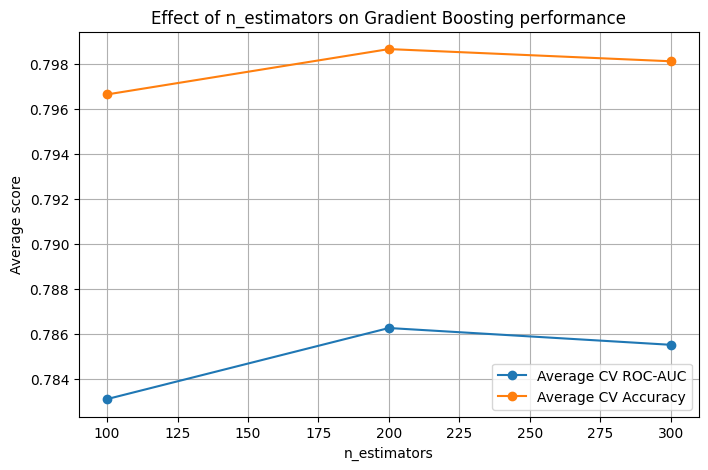

In [ ]:
n_summary = results_df.groupby("n_estimators")[["cv_roc_auc_mean", "cv_accuracy_mean"]].mean().reset_index()

plt.figure(figsize=(8,5))
plt.plot(n_summary["n_estimators"], n_summary["cv_roc_auc_mean"], marker="o", label="Average CV ROC-AUC")
plt.plot(n_summary["n_estimators"], n_summary["cv_accuracy_mean"], marker="o", label="Average CV Accuracy")
plt.xlabel("n_estimators")
plt.ylabel("Average score")
plt.title("Effect of n_estimators on Gradient Boosting performance")
plt.legend()
plt.grid()
plt.show()

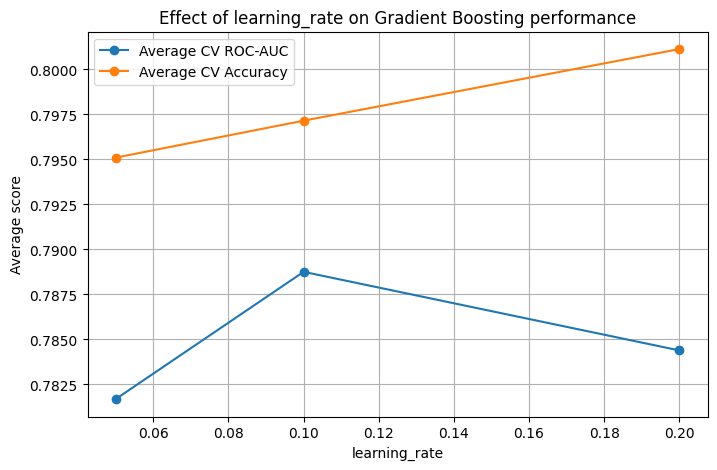

In [ ]:
lr_summary = results_df.groupby("learning_rate")[["cv_roc_auc_mean", "cv_accuracy_mean"]].mean().reset_index()

plt.figure(figsize=(8,5))
plt.plot(lr_summary["learning_rate"], lr_summary["cv_roc_auc_mean"], marker="o", label="Average CV ROC-AUC")
plt.plot(lr_summary["learning_rate"], lr_summary["cv_accuracy_mean"], marker="o", label="Average CV Accuracy")
plt.xlabel("learning_rate")
plt.ylabel("Average score")
plt.title("Effect of learning_rate on Gradient Boosting performance")
plt.legend()
plt.grid()
plt.show()

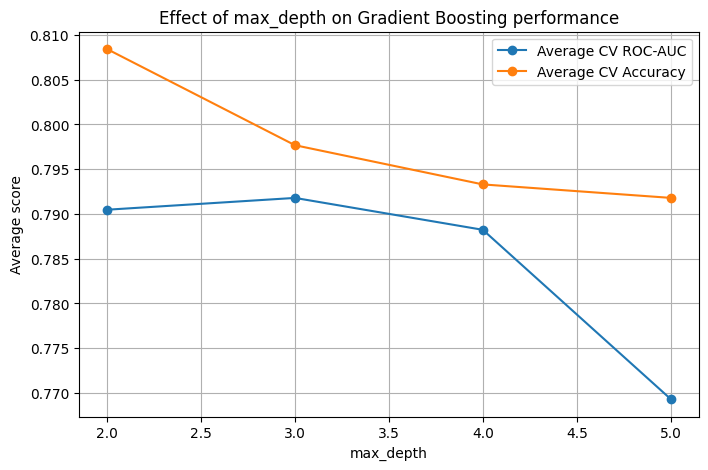

In [ ]:
depth_summary = results_df.groupby("max_depth")[["cv_roc_auc_mean", "cv_accuracy_mean"]].mean().reset_index()

plt.figure(figsize=(8,5))
plt.plot(depth_summary["max_depth"], depth_summary["cv_roc_auc_mean"], marker="o", label="Average CV ROC-AUC")
plt.plot(depth_summary["max_depth"], depth_summary["cv_accuracy_mean"], marker="o", label="Average CV Accuracy")
plt.xlabel("max_depth")
plt.ylabel("Average score")
plt.title("Effect of max_depth on Gradient Boosting performance")
plt.legend()
plt.grid()
plt.show()

## 7. Retrain best model on full training set

In [ ]:
best_gb = GradientBoostingClassifier(
    n_estimators=int(best_params["n_estimators"]),
    learning_rate=float(best_params["learning_rate"]),
    max_depth=int(best_params["max_depth"]),
    random_state=SEED
)

best_gb.fit(X_train, y_train)

print("Final Gradient Boosting model trained.")

Final Gradient Boosting model trained.


## 8. Test-set evaluation

=== Final Gradient Boosting Test Performance, threshold = 0.50 ===
              precision    recall  f1-score   support

           0       0.90      0.64      0.75        42
           1       0.88      0.97      0.92       111

    accuracy                           0.88       153
   macro avg       0.89      0.81      0.84       153
weighted avg       0.88      0.88      0.88       153

ROC-AUC: 0.9543


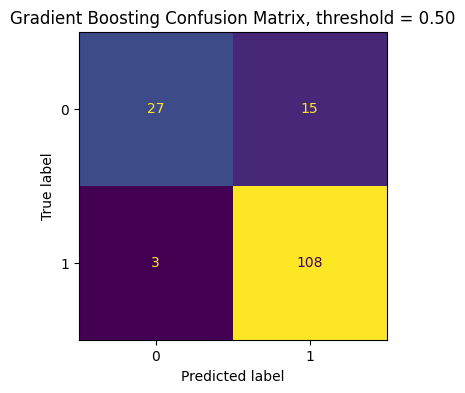

In [ ]:
proba_gb = best_gb.predict_proba(X_test)[:, 1]
pred_gb = (proba_gb >= 0.5).astype(int)

print("=== Final Gradient Boosting Test Performance, threshold = 0.50 ===")
print(classification_report(y_test, pred_gb))
print(f"ROC-AUC: {roc_auc_score(y_test, proba_gb):.4f}")

cm = confusion_matrix(y_test, pred_gb)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1]).plot(
    ax=ax,
    colorbar=False,
    values_format="d"
)
ax.set_title("Gradient Boosting Confusion Matrix, threshold = 0.50")
plt.show()

In [ ]:
## Threshold tuning

print("=== Testing threshold (best Gradient Boosting) ===")

for t in [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85]:
    pred_t = (proba_gb >= t).astype(int)
    r = classification_report(y_test, pred_t, output_dict=True)

    print(
        f"threshold={t:.2f} | "
        f"Acc={r['accuracy']:.3f} | "
        f"Recall(Healthy)={r['0']['recall']:.3f} | "
        f"Recall(PD)={r['1']['recall']:.3f} | "
        f"F1(macro)={r['macro avg']['f1-score']:.3f}"
    )

=== Testing threshold (best Gradient Boosting) ===
threshold=0.30 | Acc=0.837 | Recall(Healthy)=0.452 | Recall(PD)=0.982 | F1(macro)=0.750
threshold=0.35 | Acc=0.850 | Recall(Healthy)=0.500 | Recall(PD)=0.982 | F1(macro)=0.775
threshold=0.40 | Acc=0.863 | Recall(Healthy)=0.571 | Recall(PD)=0.973 | F1(macro)=0.804
threshold=0.45 | Acc=0.869 | Recall(Healthy)=0.595 | Recall(PD)=0.973 | F1(macro)=0.815
threshold=0.50 | Acc=0.882 | Recall(Healthy)=0.643 | Recall(PD)=0.973 | F1(macro)=0.837
threshold=0.55 | Acc=0.889 | Recall(Healthy)=0.667 | Recall(PD)=0.973 | F1(macro)=0.847
threshold=0.60 | Acc=0.895 | Recall(Healthy)=0.690 | Recall(PD)=0.973 | F1(macro)=0.857
threshold=0.65 | Acc=0.908 | Recall(Healthy)=0.738 | Recall(PD)=0.973 | F1(macro)=0.877
threshold=0.70 | Acc=0.915 | Recall(Healthy)=0.786 | Recall(PD)=0.964 | F1(macro)=0.889
threshold=0.75 | Acc=0.922 | Recall(Healthy)=0.810 | Recall(PD)=0.964 | F1(macro)=0.898
threshold=0.80 | Acc=0.928 | Recall(Healthy)=0.833 | Recall(PD)=0.964

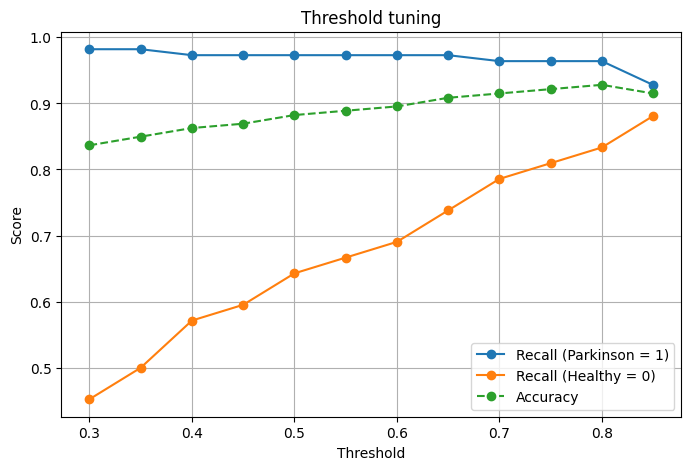

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score

# === thresholds ===
thresholds = np.linspace(0.3, 0.85, 12)

recall_pd = []
recall_healthy = []
accuracies = []

# === loop ===
for t in thresholds:
    y_pred = (proba_gb >= t).astype(int)

    report = classification_report(y_test, y_pred, output_dict=True)

    recall_pd.append(report["1"]["recall"])       # Parkinson = 1
    recall_healthy.append(report["0"]["recall"])  # Healthy = 0
    accuracies.append(accuracy_score(y_test, y_pred))

# === plot ===
plt.figure(figsize=(8,5))
plt.plot(thresholds, recall_pd, marker="o", label="Recall (Parkinson = 1)")
plt.plot(thresholds, recall_healthy, marker="o", label="Recall (Healthy = 0)")
plt.plot(thresholds, accuracies, marker="o", linestyle="--", label="Accuracy")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold tuning")
plt.legend()
plt.grid()

plt.show()

## 9. Feature importance

std_delta_delta_log_energy     0.105295
tqwt_energy_dec_27             0.043838
tqwt_TKEO_mean_dec_13          0.039398
std_7th_delta_delta            0.037173
std_6th_delta_delta            0.032819
tqwt_entropy_log_dec_34        0.025839
tqwt_energy_dec_6              0.022100
tqwt_energy_dec_21             0.021218
std_7th_delta                  0.020627
tqwt_skewnessValue_dec_25      0.019675
std_8th_delta_delta            0.019582
tqwt_TKEO_std_dec_12           0.018357
tqwt_entropy_log_dec_27        0.018240
tqwt_entropy_shannon_dec_34    0.017848
tqwt_TKEO_std_dec_19           0.017518
mean_MFCC_1st_coef             0.016512
tqwt_energy_dec_11             0.016441
tqwt_kurtosisValue_dec_16      0.016437
mean_MFCC_2nd_coef             0.016090
tqwt_energy_dec_1              0.015163
dtype: float64


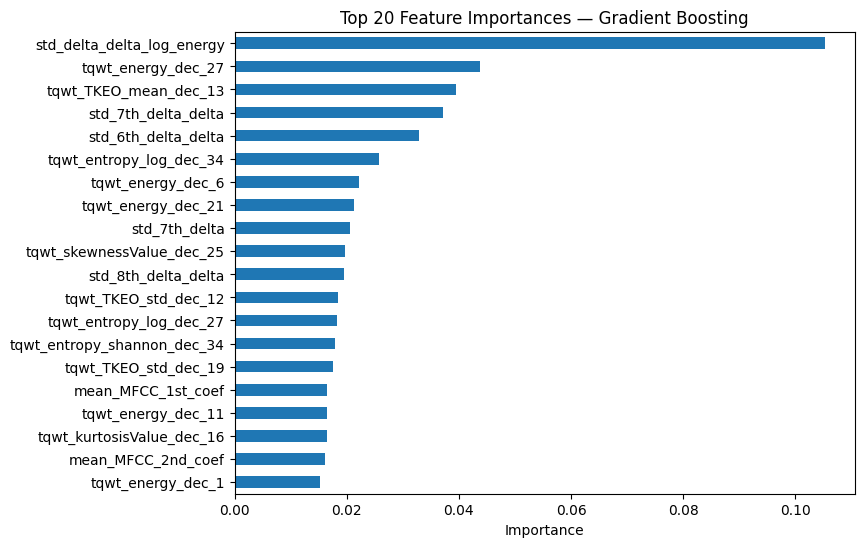

In [ ]:
importances_gb = pd.Series(best_gb.feature_importances_, index=X_train.columns)
top20_gb = importances_gb.sort_values(ascending=False).head(20)

print(top20_gb)

top20_gb.sort_values().plot(kind="barh", figsize=(8, 6))

plt.xlabel("Importance")
plt.title("Top 20 Feature Importances — Gradient Boosting")

plt.show()

# Gradient Boosting Summary

- We trained a Gradient Boosting classifier using grouped train/test splitting and 5-fold GroupKFold cross-validation to avoid patient leakage.

- The main hyperparameters tuned were:
  - `n_estimators`
  - `learning_rate`
  - `max_depth`

- The best configuration was:
  - `n_estimators = 100`
  - `learning_rate = 0.20`
  - `max_depth = 3`

- Gradient Boosting achieved the best overall performance among our ensemble models:
  - **ROC-AUC ≈ 0.95**
  - **Accuracy ≈ 0.88**

- The model achieved very high recall for Parkinson’s patients (**≈ 0.97**), meaning very few diseased patients were missed.

- Threshold tuning showed the expected tradeoff between:
  - **Sensitivity** (detecting Parkinson’s cases)
  - **Specificity** (correctly identifying healthy individuals)

- Feature importance analysis showed that several speech-related features contributed strongly to the predictions, especially:
  - `std_delta_delta_log_energy`
  - `tqwt_energy_dec_27`
  - `tqwt_TKEO_mean_dec_13`

- Overall, Gradient Boosting provided the strongest balance between predictive performance and robustness, making it the best-performing model in our study.